# 02 — Effective Stress and Pore-Water Pressure

**Short course:** *Geomorphological Hazards of Slopes* &nbsp;•&nbsp; University of Silesia in Katowice &nbsp;•&nbsp; 2 ECTS

*Lecturer: Ola Fredin*

---

In 1925, Karl Terzaghi noticed that a saturated soil deforms and fails as if the only stress that mattered to it was the *difference* between the total stress and the pressure of the water in its pores. That observation — Terzaghi's **principle of effective stress** — is the single most important idea in soil mechanics. Everything we will do in the next few notebooks (Mohr–Coulomb, infinite-slope stability, rainfall triggering) is a consequence of it.


## About this notebook

**Learning objectives.** By the end of this notebook the student will be able to:

1. State Terzaghi's principle and apply it to vertical stress profiles in saturated soil.
2. Sketch and compute the total stress, pore-water pressure, and effective stress as a function of depth.
3. Explain why a rising water table reduces effective stress *without* changing total stress, and connect this to rainfall-triggered slope failure.
4. Recognise the four canonical loading scenarios (drained loading, undrained loading, drawdown, reservoir filling) and their opposite effects on $\sigma'$.

**Prerequisites.** Lecture on *Soil mechanics and slope stability*. No prior notebook required — this is the first soil-mechanics notebook.

> **For your PowerPoint deck.** Three SVG figures land in `figures/`:
> - `effective_stress_profile.svg` — the canonical three-panel $\sigma_v$, $u$, $\sigma'_v$ profile
> - `water_table_shift.svg` — overlay of two profiles showing what rainfall does
> - `effective_stress_bars.svg` — bar diagram at a single depth, before vs. after rain


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from style import apply_style, COLORS, save_figure
apply_style()

from ipywidgets import interact, FloatSlider

GAMMA_W = 9.81  # unit weight of water [kN/m^3]


## 1. Terzaghi's principle

Imagine a tiny element of saturated soil. Its grain skeleton is in contact at the grain–grain contacts; the gaps between grains are filled with water. A total stress $\sigma$ applied externally is shared between the two:

$$
\boxed{\;\sigma \;=\; \sigma' \;+\; u\;}
\qquad (1)
$$

where $u$ is the **pore-water pressure** and $\sigma'$ is the **effective stress** — the stress carried by the grain skeleton at its contacts. The same identity holds for any direction of normal stress (vertical, horizontal, on an inclined slip surface).

**Why this matters.** Strength and deformation of soil depend on $\sigma'$, not on $\sigma$:

- Shear strength: $\tau_f = c' + \sigma'\tan\varphi'$ &nbsp;(Mohr–Coulomb, see notebook 03)
- Compression: settlement is driven by changes in $\sigma'$, not $\sigma$.

Water cannot resist shear and cannot stop grains from sliding past each other. The skeleton can. So the skeleton's share of the load is what controls everything that geotechnical engineers care about.

The cartoon in the figure below makes this concrete. A saturated soil element is a **grain skeleton** (brown) bathed in **pore water** (blue) at pressure $u$. The external load $\sigma$ pressing on top of the element is shared between the two phases: the water carries $u$ isotropically through the pores, and the grain skeleton carries the **remainder**, $\sigma' = \sigma - u$, transmitted as point loads at the grain-to-grain contacts (red arrows). The grains themselves are essentially incompressible at engineering stress levels — all the deformation, and all the strength, lives in those contacts.

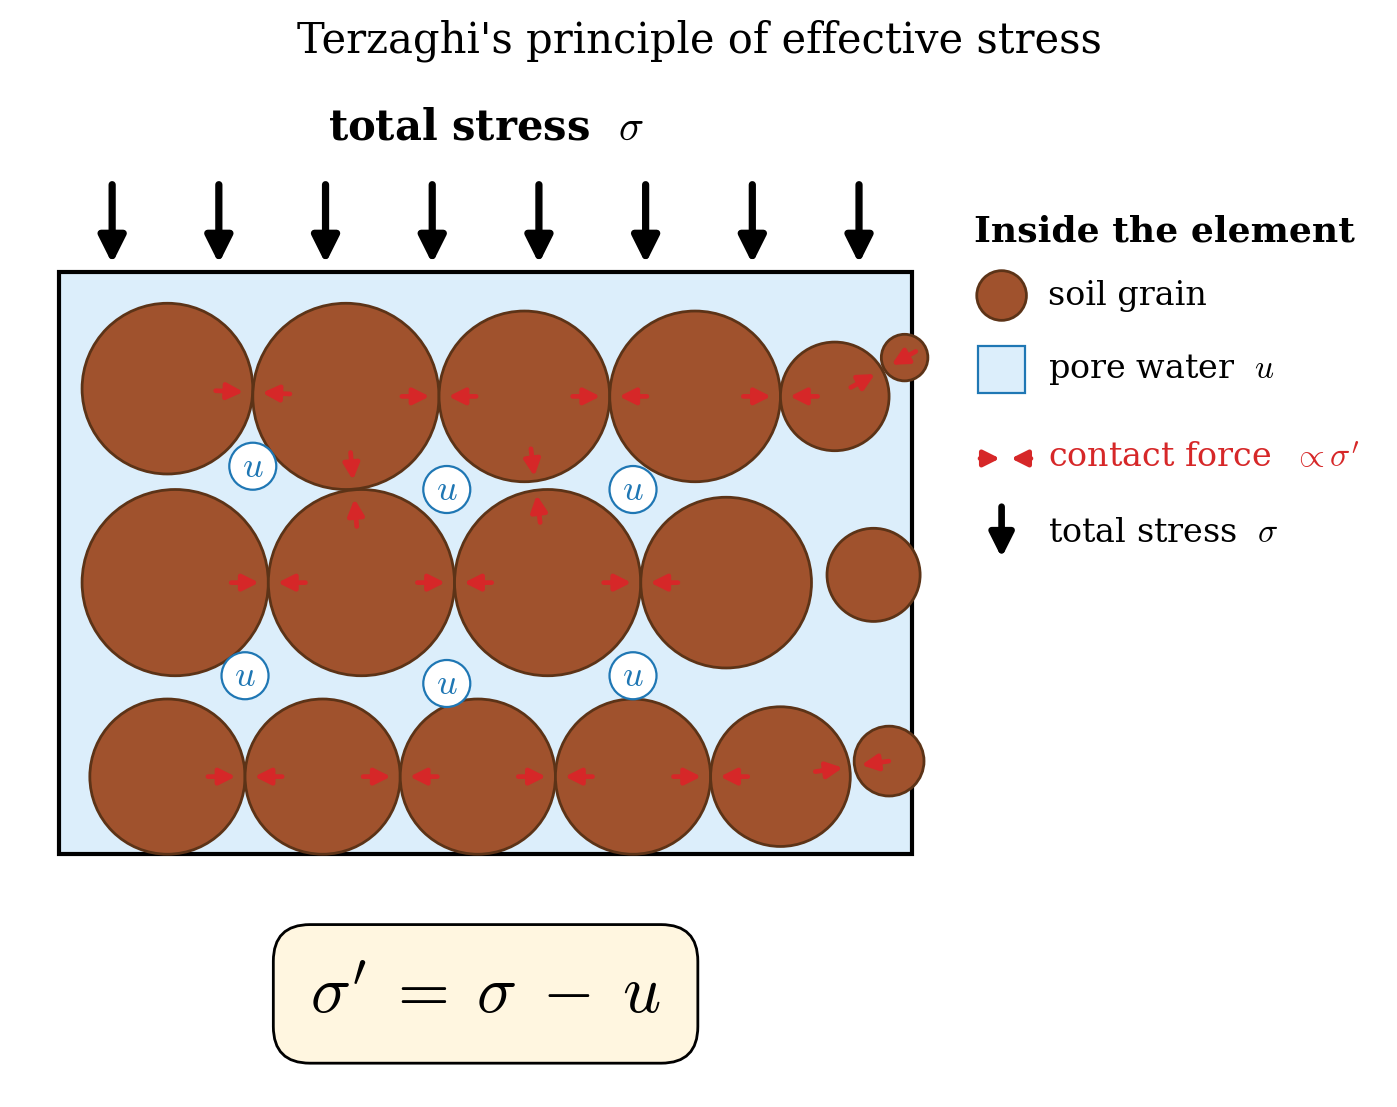

In [ ]:
# Terzaghi-principle illustration: grain skeleton + pore water + sigma arrows.
# The figure is saved to figures/terzaghi_principle.{svg,png} so it can be
# dropped straight into the PowerPoint deck.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9.5, 6.5))

BX0, BY0, BX1, BY1 = 0.0, 0.0, 11.0, 7.5
WATER_FILL = "#DCEEFB"
WATER_EDGE = COLORS["water"]
GRAIN_FILL = COLORS["soil"]
GRAIN_EDGE = "#5C3317"
CONTACT    = COLORS["fail"]

# Soil element box (background = water)
ax.add_patch(plt.Rectangle((BX0, BY0), BX1 - BX0, BY1 - BY0,
                           facecolor=WATER_FILL, edgecolor="black",
                           linewidth=1.5, zorder=1))

# Hand-placed grains (cx, cy, r) — three rows, several tangent contacts.
grains = [
    (1.4, 1.0, 1.0), (3.4, 1.0, 1.0), (5.4, 1.0, 1.0), (7.4, 1.0, 1.0),
    (9.3, 1.0, 0.9), (10.7, 1.2, 0.45),
    (1.5, 3.5, 1.2), (3.9, 3.5, 1.2), (6.3, 3.5, 1.2), (8.6, 3.5, 1.1),
    (10.5, 3.6, 0.6),
    (1.4, 6.0, 1.1), (3.7, 5.9, 1.2), (6.0, 5.9, 1.1), (8.2, 5.9, 1.1),
    (10.0, 5.9, 0.7), (10.9, 6.4, 0.3),
]
for cx, cy, r in grains:
    ax.add_patch(plt.Circle((cx, cy), r, facecolor=GRAIN_FILL,
                            edgecolor=GRAIN_EDGE, linewidth=1.0, zorder=2))

# Contact-force arrows at every tangent contact (sigma' transmitted grain-to-grain)
TOL = 0.18
for i, (cx1, cy1, r1) in enumerate(grains):
    for cx2, cy2, r2 in grains[i + 1:]:
        dx, dy = cx2 - cx1, cy2 - cy1
        d = np.hypot(dx, dy)
        if d > r1 + r2 + TOL or d < 1e-6:
            continue
        ux, uy = dx / d, dy / d
        cpx = cx1 + ux * (d + r1 - r2) / 2.0
        cpy = cy1 + uy * (d + r1 - r2) / 2.0
        L = 0.55
        ax.annotate("", xy=(cpx - ux * 0.05, cpy - uy * 0.05),
                    xytext=(cpx - ux * L, cpy - uy * L),
                    arrowprops=dict(arrowstyle="-|>", color=CONTACT,
                                    lw=1.7, mutation_scale=12), zorder=4)
        ax.annotate("", xy=(cpx + ux * 0.05, cpy + uy * 0.05),
                    xytext=(cpx + ux * L, cpy + uy * L),
                    arrowprops=dict(arrowstyle="-|>", color=CONTACT,
                                    lw=1.7, mutation_scale=12), zorder=4)

# Total stress sigma — eight thick arrows pressing on top
ax.text((BX0 + BX1) / 2, BY1 + 1.6, r"total stress  $\sigma$",
        ha="center", va="bottom", fontsize=15, fontweight="bold")
for k in range(8):
    x = BX0 + (k + 0.5) * (BX1 - BX0) / 8
    ax.annotate("", xy=(x, BY1 + 0.04), xytext=(x, BY1 + 1.2),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=2.6, mutation_scale=20), zorder=3)

# u labels in a few pores
for x, y in [(2.5, 5.0), (5.0, 4.7), (7.4, 4.7),
             (2.4, 2.3), (5.0, 2.2), (7.4, 2.3)]:
    ax.text(x, y, r"$u$", color=WATER_EDGE, fontsize=13,
            ha="center", va="center", fontweight="bold", zorder=5,
            bbox=dict(boxstyle="circle,pad=0.18", facecolor="white",
                      edgecolor=WATER_EDGE, lw=0.8))

# Right-side legend
lx, ly0 = BX1 + 0.8, BY1 + 0.4
ax.text(lx, ly0, "Inside the element", fontsize=13, fontweight="bold")
ax.add_patch(plt.Circle((lx + 0.35, ly0 - 0.7), 0.32,
                        facecolor=GRAIN_FILL, edgecolor=GRAIN_EDGE, lw=1.0))
ax.text(lx + 0.95, ly0 - 0.7, "soil grain", fontsize=12, va="center")
ax.add_patch(plt.Rectangle((lx + 0.05, ly0 - 1.95), 0.6, 0.6,
                           facecolor=WATER_FILL, edgecolor=WATER_EDGE, lw=0.8))
ax.text(lx + 0.95, ly0 - 1.65, r"pore water  $u$", fontsize=12, va="center")
cy_leg = ly0 - 2.8
ax.annotate("", xy=(lx + 0.4, cy_leg), xytext=(lx + 0.0, cy_leg),
            arrowprops=dict(arrowstyle="-|>", color=CONTACT,
                            lw=1.7, mutation_scale=12))
ax.annotate("", xy=(lx + 0.4, cy_leg), xytext=(lx + 0.8, cy_leg),
            arrowprops=dict(arrowstyle="-|>", color=CONTACT,
                            lw=1.7, mutation_scale=12))
ax.text(lx + 0.95, cy_leg, r"contact force  $\propto \sigma'$",
        fontsize=12, va="center", color=CONTACT)
sy_leg = ly0 - 3.9
ax.annotate("", xy=(lx + 0.35, sy_leg - 0.25),
            xytext=(lx + 0.35, sy_leg + 0.55),
            arrowprops=dict(arrowstyle="-|>", color="black",
                            lw=2.4, mutation_scale=18))
ax.text(lx + 0.95, sy_leg + 0.15, r"total stress  $\sigma$",
        fontsize=12, va="center")

# Boxed equation
ax.text((BX0 + BX1) / 2, BY0 - 1.8, r"$\sigma'\;=\;\sigma\;-\;u$",
        fontsize=24, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.55",
                  facecolor="#FFF6E0", edgecolor="black", lw=1.0))

ax.set_xlim(BX0 - 0.5, BX1 + 6.0)
ax.set_ylim(BY0 - 3.0, BY1 + 2.4)
ax.set_aspect("equal"); ax.grid(False); ax.axis("off")
ax.set_title("Terzaghi's principle of effective stress", pad=12, fontsize=15)

save_figure(fig, "terzaghi_principle")
plt.show()

## 2. Vertical stress profiles in saturated ground

Consider a uniform soil column with unit weight $\gamma$. The ground surface is at $z = 0$; depth $z$ increases downward. A horizontal water table sits at depth $z_w$. Below it, pore-water pressure is hydrostatic.

The vertical stress at depth $z$ is the weight of soil above:

$$
\sigma_v(z) \;=\; \gamma\, z
\qquad (2)
$$

The pore-water pressure is

$$
u(z) \;=\;
\begin{cases}
0 & \text{if } z \leq z_w \\
\gamma_w\,(z - z_w) & \text{if } z > z_w
\end{cases}
\qquad (3)
$$

The effective vertical stress follows from Terzaghi's principle:

$$
\sigma'_v(z) \;=\; \sigma_v(z) - u(z)
\qquad (4)
$$

The kink in $\sigma'_v$ at the water table is the most diagnostic feature of any soil-mechanics depth plot.


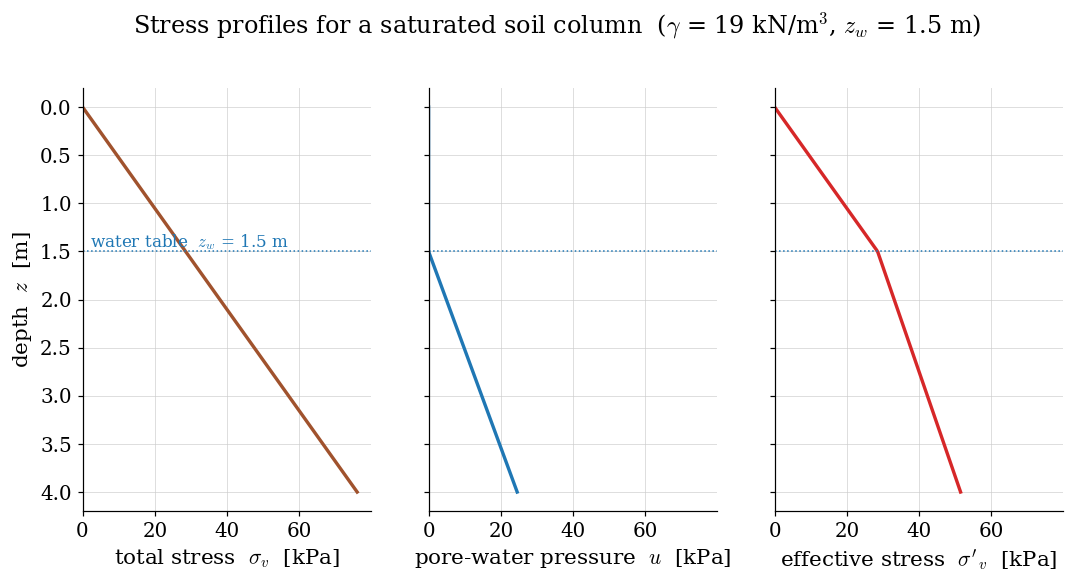

In [2]:
def stress_profiles(z, gamma, z_w):
    """Total vertical stress, pore-water pressure, effective vertical stress."""
    sigma_v = gamma * z
    u = np.where(z > z_w, GAMMA_W * (z - z_w), 0.0)
    sigma_v_eff = sigma_v - u
    return sigma_v, u, sigma_v_eff


def plot_stress_profile(gamma=19.0, z_w=1.5, z_max=4.0, ax_set=None, label=None):
    """Three-panel plot: sigma_v, u, sigma'_v vs depth."""
    z = np.linspace(0, z_max, 200)
    sigma_v, u, sigma_v_eff = stress_profiles(z, gamma, z_w)

    if ax_set is None:
        fig, ax_set = plt.subplots(1, 3, figsize=(11.5, 5.0), sharey=True)
    else:
        fig = ax_set[0].figure

    titles = [r"total stress  $\sigma_v$  [kPa]",
              r"pore-water pressure  $u$  [kPa]",
              r"effective stress  $\sigma'_v$  [kPa]"]
    series = [sigma_v, u, sigma_v_eff]
    colours = [COLORS["soil"], COLORS["water"], COLORS["fail"]]

    for ax, x, c, t in zip(ax_set, series, colours, titles):
        ax.plot(x, z, color=c, lw=2.2, label=label)
        ax.axhline(z_w, color=COLORS["water"], lw=1.0, ls=":")
        ax.set_xlabel(t)
        ax.set_xlim(0, max(sigma_v.max() * 1.05, 1))

    ax_set[0].set_ylabel("depth  $z$  [m]")
    ax_set[0].invert_yaxis()
    ax_set[0].text(2, z_w - 0.05, fr"water table  $z_w$ = {z_w:.1f} m",
                   color=COLORS["water"], fontsize=11)
    return fig, ax_set


fig, _ = plot_stress_profile(gamma=19.0, z_w=1.5, z_max=4.0)
fig.suptitle(r"Stress profiles for a saturated soil column  "
             r"($\gamma$ = 19 kN/m$^3$, $z_w$ = 1.5 m)", y=1.02)
save_figure(fig, "effective_stress_profile")
plt.show()


## 3. The same total stress; different effective stress

Two soil columns of identical density and identical thickness can carry the *same total stress* yet behave completely differently — one strong, one verging on collapse — if their water tables sit at different depths. The total-stress profile $\sigma_v = \gamma z$ is the *same* in both columns; what differs is $u$, and hence $\sigma'_v$.

This is the mechanical reason rainfall, snowmelt, and reservoir filling can trigger landslides without any new load being placed on the slope. They do not add weight; they raise $u$, which subtracts from $\sigma'$, which weakens the soil.


## 4. What rainfall does to the profile

Below, the same soil column is plotted twice: once with the water table at $z_w = 1.5$ m (pre-rainstorm) and once with $z_w = 0.2$ m (after several days of heavy rain). Total stress is identical in both cases — there is no new soil, no new load. Pore pressure increases everywhere below the new water table, and effective stress drops by the same amount.


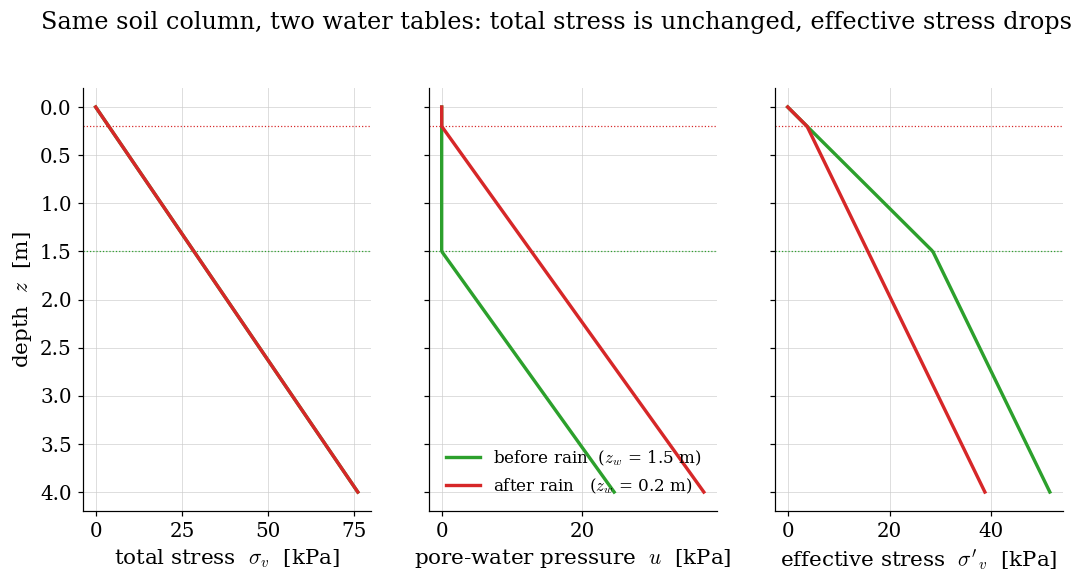

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 5.0), sharey=True)

# Two scenarios overlaid
z = np.linspace(0, 4.0, 200)
gamma = 19.0

for z_w, colour_scheme, label in [
    (1.5, COLORS["safe"],   "before rain  ($z_w$ = 1.5 m)"),
    (0.2, COLORS["fail"],   "after rain   ($z_w$ = 0.2 m)"),
]:
    sigma_v, u, sigma_v_eff = stress_profiles(z, gamma, z_w)
    axes[0].plot(sigma_v,     z, color=colour_scheme, lw=2.2, label=label)
    axes[1].plot(u,           z, color=colour_scheme, lw=2.2, label=label)
    axes[2].plot(sigma_v_eff, z, color=colour_scheme, lw=2.2, label=label)
    for ax in axes:
        ax.axhline(z_w, color=colour_scheme, lw=0.8, ls=":")

axes[0].set_xlabel(r"total stress  $\sigma_v$  [kPa]")
axes[1].set_xlabel(r"pore-water pressure  $u$  [kPa]")
axes[2].set_xlabel(r"effective stress  $\sigma'_v$  [kPa]")
axes[0].set_ylabel("depth  $z$  [m]")
axes[0].invert_yaxis()
axes[1].legend(loc="lower right", fontsize=11)

fig.suptitle("Same soil column, two water tables: total stress is unchanged, effective stress drops",
             y=1.02)
save_figure(fig, "water_table_shift")
plt.show()


## 5. Interactive exploration

Move the water-table slider and watch the three profiles update. Two things to notice:

- The $\sigma_v$ profile **does not move** — total stress depends only on the soil column above, not on water content.
- $u$ is bounded below by zero (we ignore suction here, but see §8). It is a piecewise function with a kink at the water table.


In [ ]:
def explore(z_w=1.5, gamma=19.0, z_max=4.0):
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.8), sharey=True)
    plot_stress_profile(gamma=gamma, z_w=z_w, z_max=z_max, ax_set=axes)
    fig.suptitle(fr"$z_w$ = {z_w:.2f} m,  $\gamma$ = {gamma:.1f} kN/m$^3$",
                 y=1.02)
    plt.show()


interact(
    explore,
    z_w  =FloatSlider(min=0.0, max=4.0, step=0.05, value=1.5,  description="$z_w$ [m]"),
    gamma=FloatSlider(min=15.0, max=22.0, step=0.5, value=19.0, description=r"$\gamma$ [kN/m$^3$]"),
    z_max=FloatSlider(min=2.0, max=6.0, step=0.5, value=4.0,   description="$z_{max}$ [m]"),
);


interactive(children=(FloatSlider(value=1.5, description='$z_w$ [m]', max=4.0, step=0.05), FloatSlider(value=1…

## 6. Four scenarios that change $\sigma'$

Whether a stress change reaches the grain skeleton or is briefly carried entirely by the pore water depends on whether water can drain in or out of the loaded zone fast enough. The four canonical cases:

| Scenario | What changes | $\Delta\sigma$ | $\Delta u$ | $\Delta\sigma'$ | Example |
|---|---|---|---|---|---|
| Drained loading | Slow loading of a free-draining soil | $\uparrow$ | $0$ | $\uparrow$ | Spoil pile on sand |
| Undrained loading | Fast loading of a clay (water trapped) | $\uparrow$ | $\uparrow$ | $0$ | Embankment over peat, first day |
| Reservoir filling / rainfall | $u$ rises with no new load | $0$ | $\uparrow$ | $\downarrow$ | Vajont 1963; Carpathian rainstorm |
| Rapid drawdown / drainage | $u$ drops with no load change | $0$ | $\downarrow$ | $\uparrow$ | Dam drainage; horizontal drains in a slope |

The third row is the one that matters most for landslide triggering. The fourth row is the mechanical basis for **slope drainage** as a stabilisation measure — it costs nothing in terms of slope geometry yet recovers the lost effective stress.


## 7. Worked example: Carpathian flysch slope

We use the same soil column that will reappear in notebooks 03 and 04: a Carpathian flysch with $\gamma = 19$ kN/m³. Take the depth of interest as $z = 2.0$ m (the depth of the slip surface in a typical shallow translational slide). The infinite-slope analysis of notebook 04 uses the saturation fraction $m = (z - z_w)/z$ instead of $z_w$; the two scenarios there were $m = 0.3$ (pre-rain) and $m = 0.9$ (post-rain), which corresponds to $z_w = 1.4$ m and $z_w = 0.2$ m here.

> *Note.* In a horizontal soil column the normal stress on a horizontal plane is the full $\sigma_v$. On an inclined slope, the normal stress on a plane parallel to the slope is $\sigma_n = \gamma z \cos^2\beta$. The slope correction is treated in notebook 04. For now we work in the vertical case to keep the focus on $\sigma'$.


At depth z = 2.0 m
------------------------------------------------------------
scenario                         sigma_v       u   sigma_v_eff
------------------------------------------------------------
before rain  ($z_w$ = 1.4 m)       38.00    5.89         32.11
after rain   ($z_w$ = 0.2 m)       38.00   17.66         20.34
------------------------------------------------------------


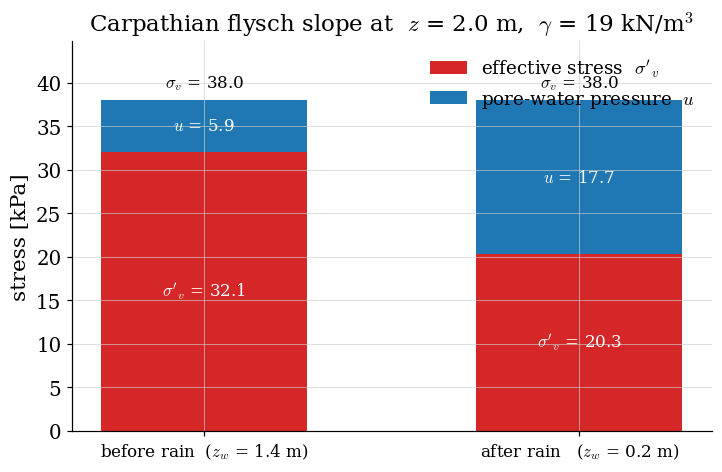


Effective stress dropped from 32.1 to 20.3 kPa  --  a 37% reduction with no change in total stress.


In [6]:
z = 2.0          # depth of interest [m]
gamma = 19.0     # unit weight of soil [kN/m^3]

scenarios = {
    "before rain  ($z_w$ = 1.4 m)": 1.4,
    "after rain   ($z_w$ = 0.2 m)": 0.2,
}

print(f"At depth z = {z:.1f} m")
print("-" * 60)
print(f"{'scenario':<32}{'sigma_v':>8}{'u':>8}{'sigma_v_eff':>14}")
print("-" * 60)
results = {}
for label, z_w in scenarios.items():
    sig, u, sig_eff = stress_profiles(np.array([z]), gamma, z_w)
    results[label] = (float(sig[0]), float(u[0]), float(sig_eff[0]))
    print(f"{label:<32}{sig[0]:>8.2f}{u[0]:>8.2f}{sig_eff[0]:>14.2f}")
print("-" * 60)

# Stacked-bar diagram: sigma_v = sigma'_v + u, before vs. after rain.
fig, ax = plt.subplots(figsize=(7.5, 4.6))
labels = list(results.keys())
sig_v   = [results[k][0] for k in labels]
u_vals  = [results[k][1] for k in labels]
sig_eff = [results[k][2] for k in labels]

x = np.arange(len(labels))
w = 0.55
ax.bar(x, sig_eff, w, color=COLORS["fail"], label=r"effective stress  $\sigma'_v$")
ax.bar(x, u_vals,  w, bottom=sig_eff, color=COLORS["water"], label=r"pore-water pressure  $u$")

for i, (s_eff, u_val, s_tot) in enumerate(zip(sig_eff, u_vals, sig_v)):
    ax.text(i, s_eff / 2,            fr"$\sigma'_v$ = {s_eff:.1f}", ha="center", va="center", fontsize=11, color="white")
    ax.text(i, s_eff + u_val / 2,    fr"$u$ = {u_val:.1f}",          ha="center", va="center", fontsize=11, color="white")
    ax.text(i, s_tot + 1.0,          fr"$\sigma_v$ = {s_tot:.1f}",  ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("stress [kPa]")
ax.set_ylim(0, max(sig_v) * 1.18)
ax.set_title(fr"Carpathian flysch slope at  $z$ = {z:.1f} m,  $\gamma$ = {gamma:.0f} kN/m$^3$")
ax.legend(loc="upper right")
save_figure(fig, "effective_stress_bars")
plt.show()

drop = results[labels[0]][2] - results[labels[1]][2]
pct  = 100 * drop / results[labels[0]][2]
print(f"\nEffective stress dropped from {results[labels[0]][2]:.1f} to "
      f"{results[labels[1]][2]:.1f} kPa  --  a {pct:.0f}% reduction "
      f"with no change in total stress.")


## 8. A short note on suction

Above the water table the pores are only partly filled with water. Surface tension at the air–water menisci pulls grains together — this is **suction**, equivalent to a *negative* pore-water pressure. In equation (1), $u < 0$ above the water table, so $\sigma' > \sigma$.

The practical effect is **apparent cohesion**: damp sand stands at near-vertical in a sand castle, while dry sand or fully saturated sand cannot. The apparent cohesion is fragile — it disappears as soon as either the suction drains away (drying) or the pores fill (saturation). Many shallow Central-European slides initiate when a rainstorm both *destroys the suction* in the upper unsaturated zone and *raises the water table* in the deeper saturated zone.

We will not model suction explicitly in this course. For a quantitative treatment see Lu and Likos (2004) *Unsaturated Soil Mechanics* (Wiley).


## Take-aways

- Terzaghi's principle, $\sigma = \sigma' + u$, is the foundation of every soil-strength and slope-stability calculation we will do.
- Total stress depends only on the weight of material above; pore pressure depends on the water table and on drainage; effective stress is whatever is left.
- A rising water table raises $u$ and reduces $\sigma'$ without changing $\sigma$. That is the *mechanism* of rainfall-triggered slope failure.
- Drainage is the inverse operation: it lowers $u$ and recovers $\sigma'$, which is why it is one of the cheapest and most reliable slope-stabilisation measures.


## Voluntary exercises

1. State Terzaghi's principle and give two consequences of it for slope stability.
2. A homogeneous soil column has $\gamma = 18$ kN/m³ and a water table at $z_w = 2.0$ m. Compute $\sigma_v$, $u$, and $\sigma'_v$ at depths $z = 1.0$ m, $z = 2.0$ m, and $z = 4.0$ m.
3. Heavy rainfall raises the water table from $z_w = 2.0$ m to $z_w = 0.5$ m in the column from question 2. By what fraction does $\sigma'_v$ at $z = 4.0$ m change? What stays the same?
4. The Vajont 1963 disaster occurred during the *filling* of a reservoir behind a dam, not during construction. Explain in terms of effective stress why filling — rather than building — was the triggering event.


## References

- Terzaghi, K. (1943). *Theoretical Soil Mechanics.* Wiley.
- Lu, N. & Likos, W. J. (2004). *Unsaturated Soil Mechanics.* Wiley.
- Lambe, T. W. & Whitman, R. V. (1969). *Soil Mechanics.* Wiley.
- Iverson, R. M. (2000). *Landslide triggering by rain infiltration.* Water Resources Research, 36(7), 1897–1910.
